Cell 1 — Imports and load data:

In [1]:
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import warnings
warnings.filterwarnings('ignore')

sc.settings.verbosity = 3
sc.settings.set_figure_params(dpi=100, facecolor='white', frameon=True)

# Load Harmony-corrected data
adata = sc.read_h5ad(os.path.expanduser("~/ATRT/Data/adata_harmony.h5ad"))
print(f"Loaded: {adata.n_obs} nuclei x {adata.n_vars} genes")

Loaded: 9604 nuclei x 36601 genes


Cell 2 — Leiden clustering:

In [2]:
# Run Leiden clustering on the Harmony-corrected SNN graph
# (neighbors were already computed in Program 4 using X_pca_harmony)
sc.tl.leiden(adata, resolution=0.5, key_added='leiden')

n_clusters = adata.obs['leiden'].nunique()
print(f"Leiden clustering complete: {n_clusters} clusters found")
print(f"\nCluster sizes:")
print(adata.obs['leiden'].value_counts().sort_index())

# ============================================================
# REPORT VALUE: "[N] clusters" — record this number
# ============================================================
print(f"\n>>> FOR REPORT: Leiden clustering yielded {n_clusters} clusters")

running Leiden clustering
    finished: found 19 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:00:00)
Leiden clustering complete: 19 clusters found

Cluster sizes:
leiden
0     2183
1     1462
2     1237
3      948
4      652
5      614
6      398
7      386
8      358
9      328
10     197
11     177
12     173
13     155
14     105
15      86
16      58
17      55
18      32
Name: count, dtype: int64

>>> FOR REPORT: Leiden clustering yielded 19 clusters


Cell 3 — UMAP colored by cluster (Figure 2C, part 1):

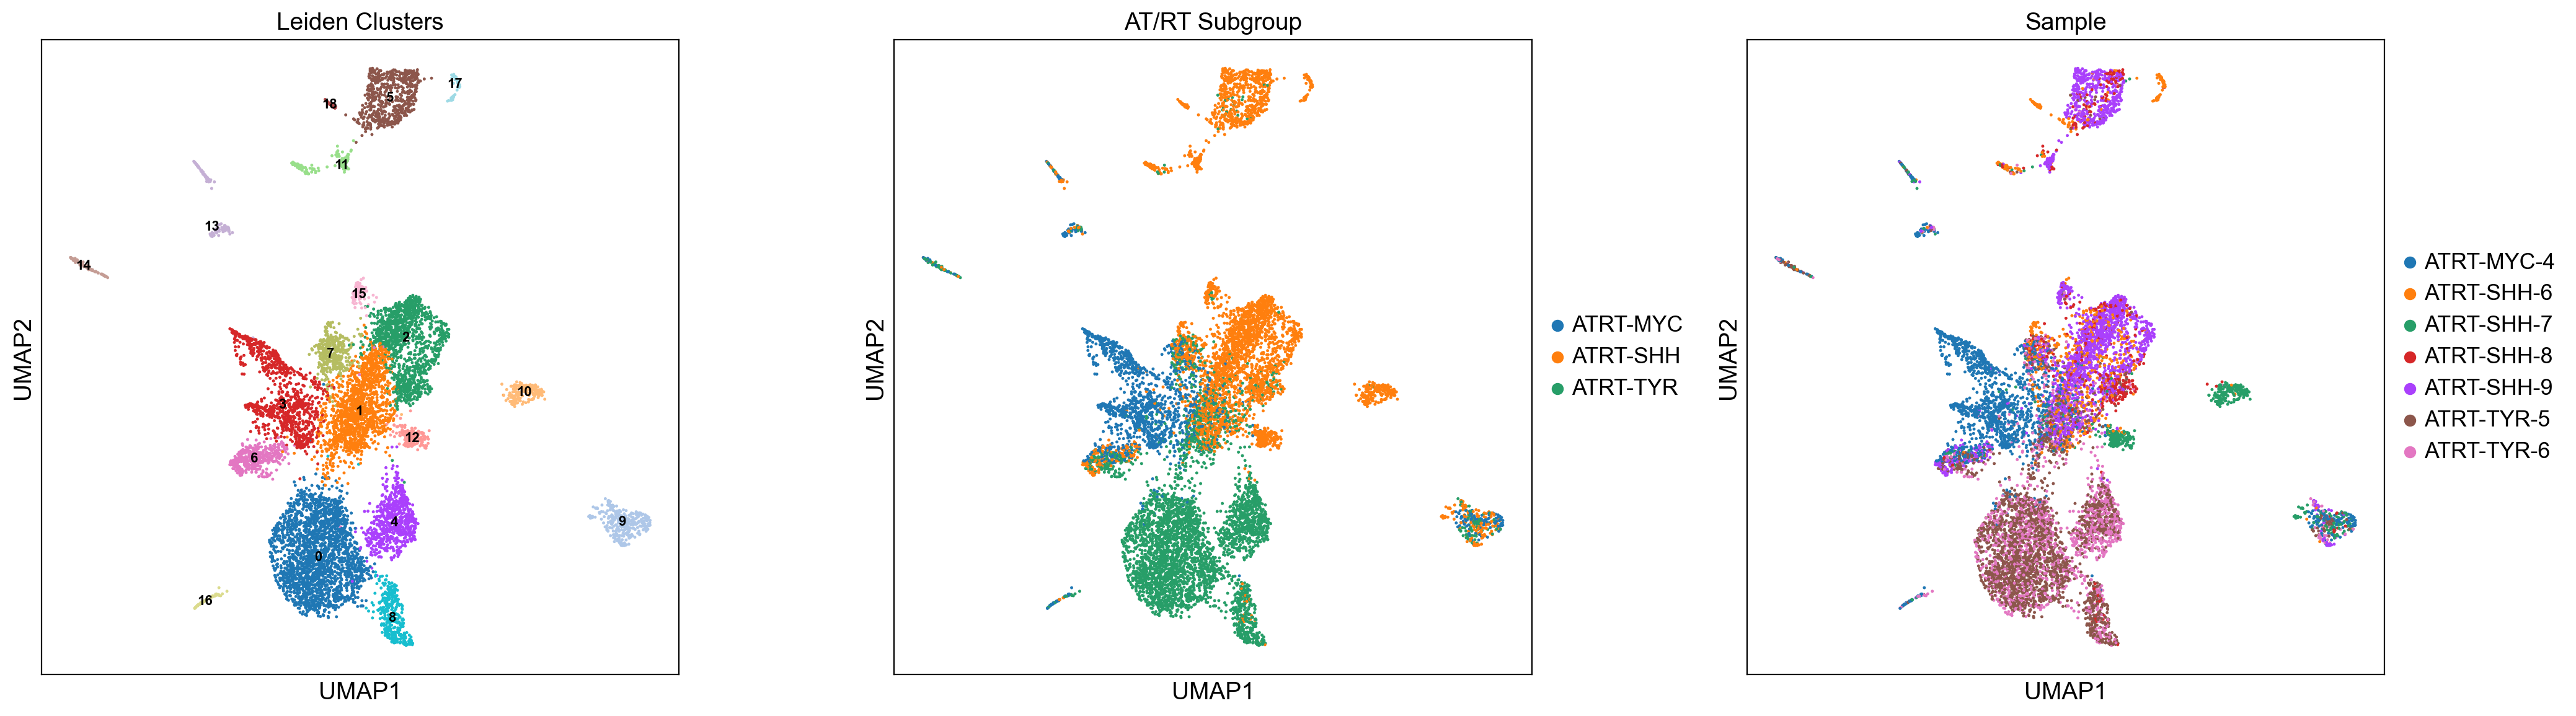


>>> FIGURE 2C (UMAP): Saved to ~/ATRT/Data/Fig2C_leiden_UMAP.png


In [3]:
# ============================================================
# FIGURE FOR REPORT: UMAP by Leiden cluster → Figure 2C
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(21, 6))

sc.pl.umap(adata, color='leiden', ax=axes[0], show=False, 
           title='Leiden Clusters', legend_loc='on data', legend_fontsize=8)
sc.pl.umap(adata, color='subgroup', ax=axes[1], show=False, title='AT/RT Subgroup')
sc.pl.umap(adata, color='sample', ax=axes[2], show=False, title='Sample')

plt.tight_layout()
plt.savefig(os.path.expanduser("~/ATRT/Data/Fig2C_leiden_UMAP.png"), dpi=300, bbox_inches='tight')
plt.show()

print("\n>>> FIGURE 2C (UMAP): Saved to ~/ATRT/Data/Fig2C_leiden_UMAP.png")

Cell 4 — Compare our clusters to authors' annotations:

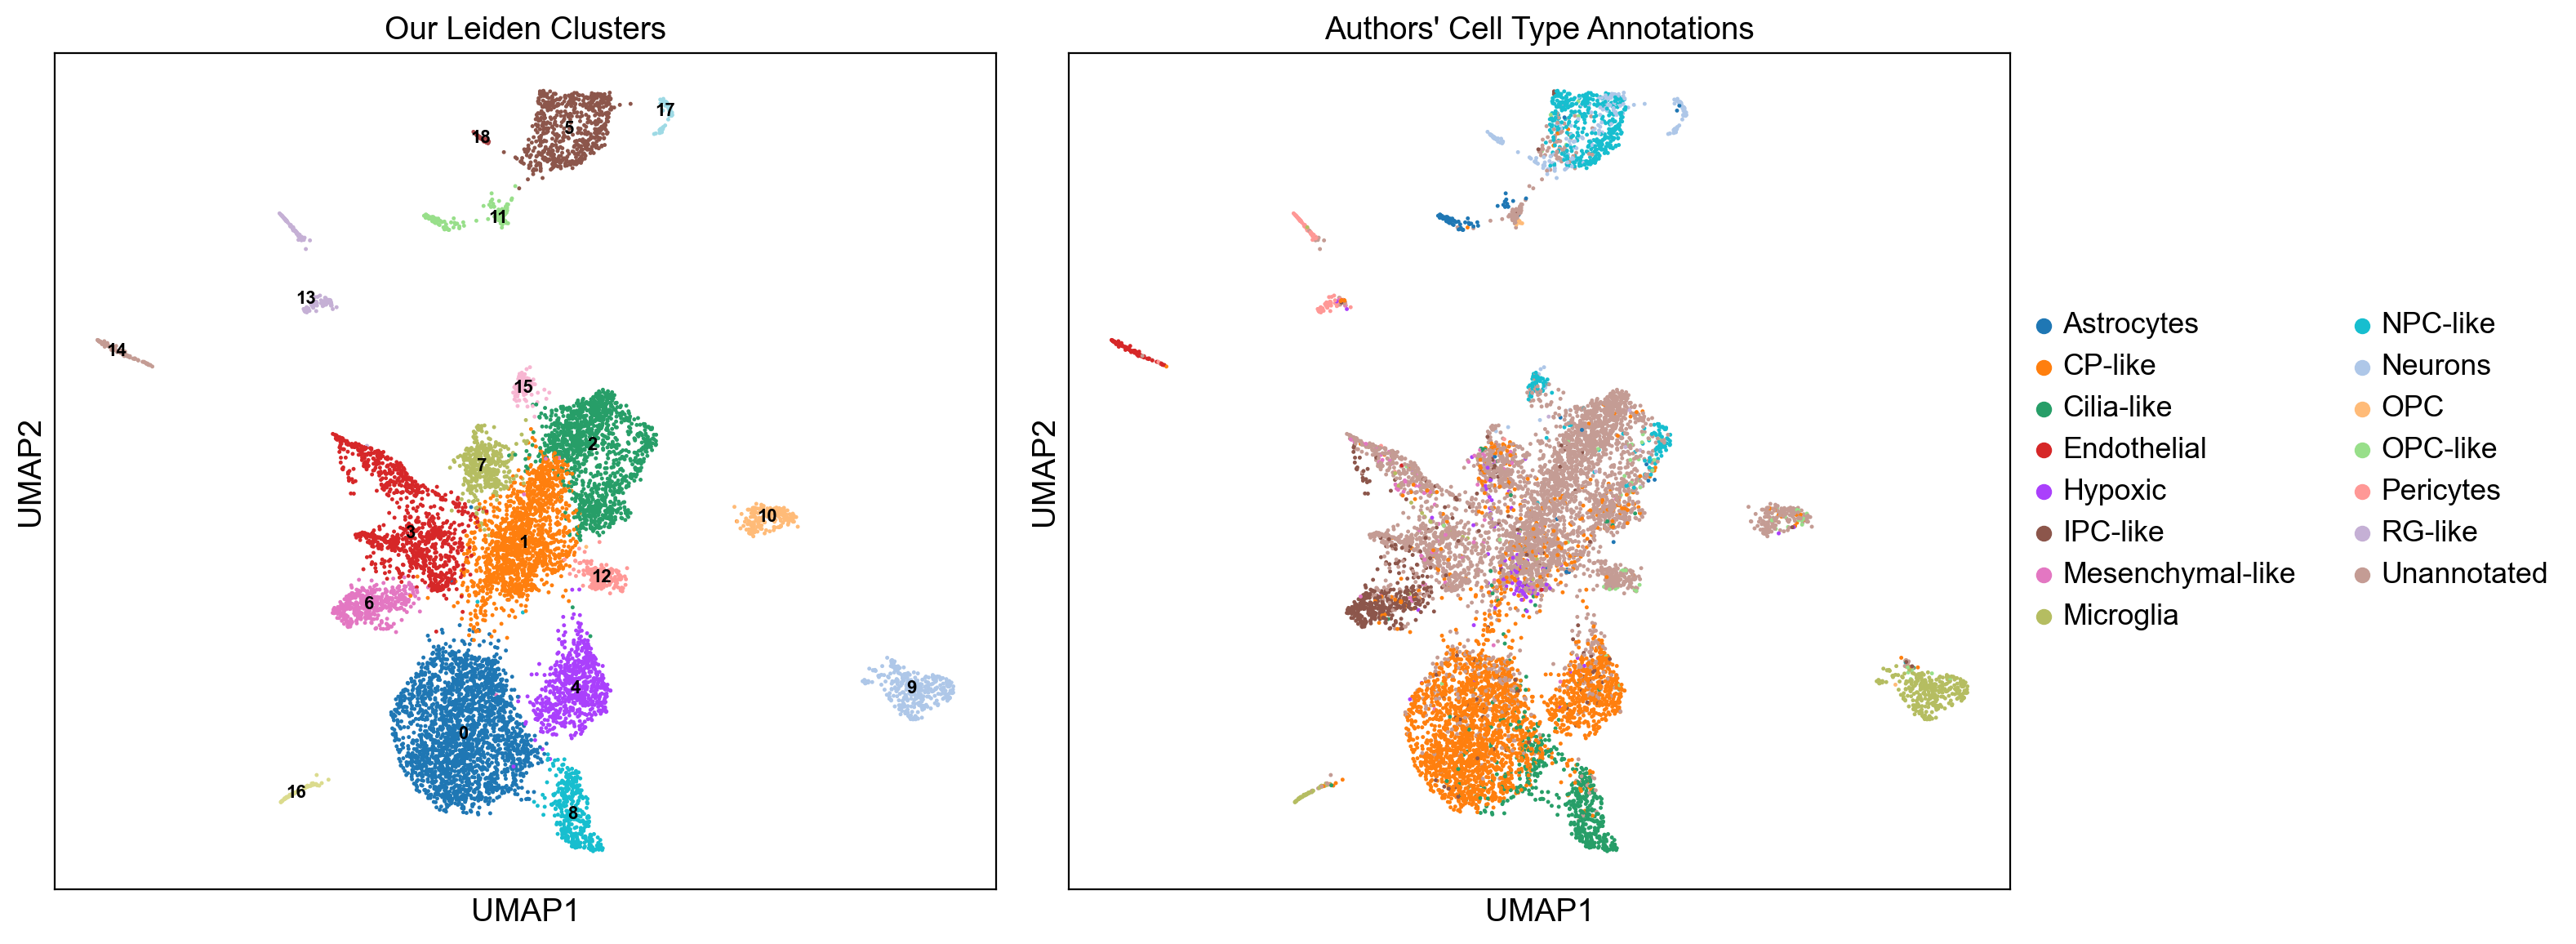


=== Cluster vs. Authors' Annotations ===
Final_Annotation  Astrocytes  CP-like  Cilia-like  Endothelial  Hypoxic  IPC-like  Mesenchymal-like  Microglia  NPC-like  Neurons  OPC  OPC-like  Pericytes  RG-like  Unannotated
leiden                                                                                                                                                                           
0                        0.0     80.8         8.1          0.0      0.3       1.3               0.1        0.0       0.0      0.0  0.0       0.0        0.0      0.0          9.4
1                        0.3     11.1         0.7          0.1      4.5       1.4               0.4        0.2       0.2      0.0  0.0       0.2        0.1      0.0         80.8
2                        0.4      4.6         0.3          0.0      0.0       0.5               0.1        0.0       6.1      0.1  0.0       1.5        0.0      0.5         85.9
3                        0.0      3.6         0.0          0.1      

In [4]:
# The authors provided cell type annotations — let's compare
# This helps guide our own annotation

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sc.pl.umap(adata, color='leiden', ax=axes[0], show=False, 
           title='Our Leiden Clusters', legend_loc='on data', legend_fontsize=8)
sc.pl.umap(adata, color='Final_Annotation', ax=axes[1], show=False, 
           title="Authors' Cell Type Annotations")

plt.tight_layout()
plt.show()

# Cross-tabulate our clusters with authors' annotations
print("\n=== Cluster vs. Authors' Annotations ===")
ct = pd.crosstab(adata.obs['leiden'], adata.obs['Final_Annotation'])
# Show as proportions per cluster (what % of each cluster is each cell type)
ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
print(ct_pct.round(1).to_string())

Cell 5 — Find cluster marker genes:

In [5]:
# Find marker genes for each cluster using Wilcoxon test
sc.tl.rank_genes_groups(adata, groupby='leiden', method='wilcoxon', use_raw=True)

# Show top 5 markers per cluster
print("=== Top 5 Marker Genes Per Cluster ===\n")
result = adata.uns['rank_genes_groups']
for cluster in sorted(adata.obs['leiden'].unique(), key=int):
    genes = result['names'][cluster][:5]
    scores = result['scores'][cluster][:5]
    print(f"Cluster {cluster}:")
    for g, s in zip(genes, scores):
        print(f"  {g} (score: {s:.1f})")
    print()

ranking genes
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:34)
=== Top 5 Marker Genes Per Cluster ===

Cluster 0:
  TRPM3 (score: 55.9)
  HTR2C (score: 54.0)
  RMST (score: 53.2)
  SAMD5 (score: 49.3)
  DISP1 (score: 46.5)

Cluster 1:
  MSMO1 (score: 4.7)
  HSPA1B (score: 4.4)
  HMGCS1 (score: 4.1)
  GPC5 (score: 4.0)
  BRINP3 (score: 4.0)

Cluster 2:
  PSD3 (score: 36.0)
  CLASP2 (score: 31.5)
  SCN3A (score: 29.5)
  CTNNA2 (score: 28.8)
  BRINP3 (score: 26.9)

Cluster 3:
  AC011287.1 (score: 45.2)
  RAD51B (score: 31.7)
  MSRB3 (score: 30.5)
  AL008633.1 (score: 29.7)
  PLCG2 (score: 28.6)

Cluster 4:
  NRXN3 (score: 24.6)
  SYNPR (score: 22.9)
  LSAMP (score: 22.3)
  

Cell 6 — Canonical marker dot plot (Figure 2C, part 2):

Markers found: 19/19


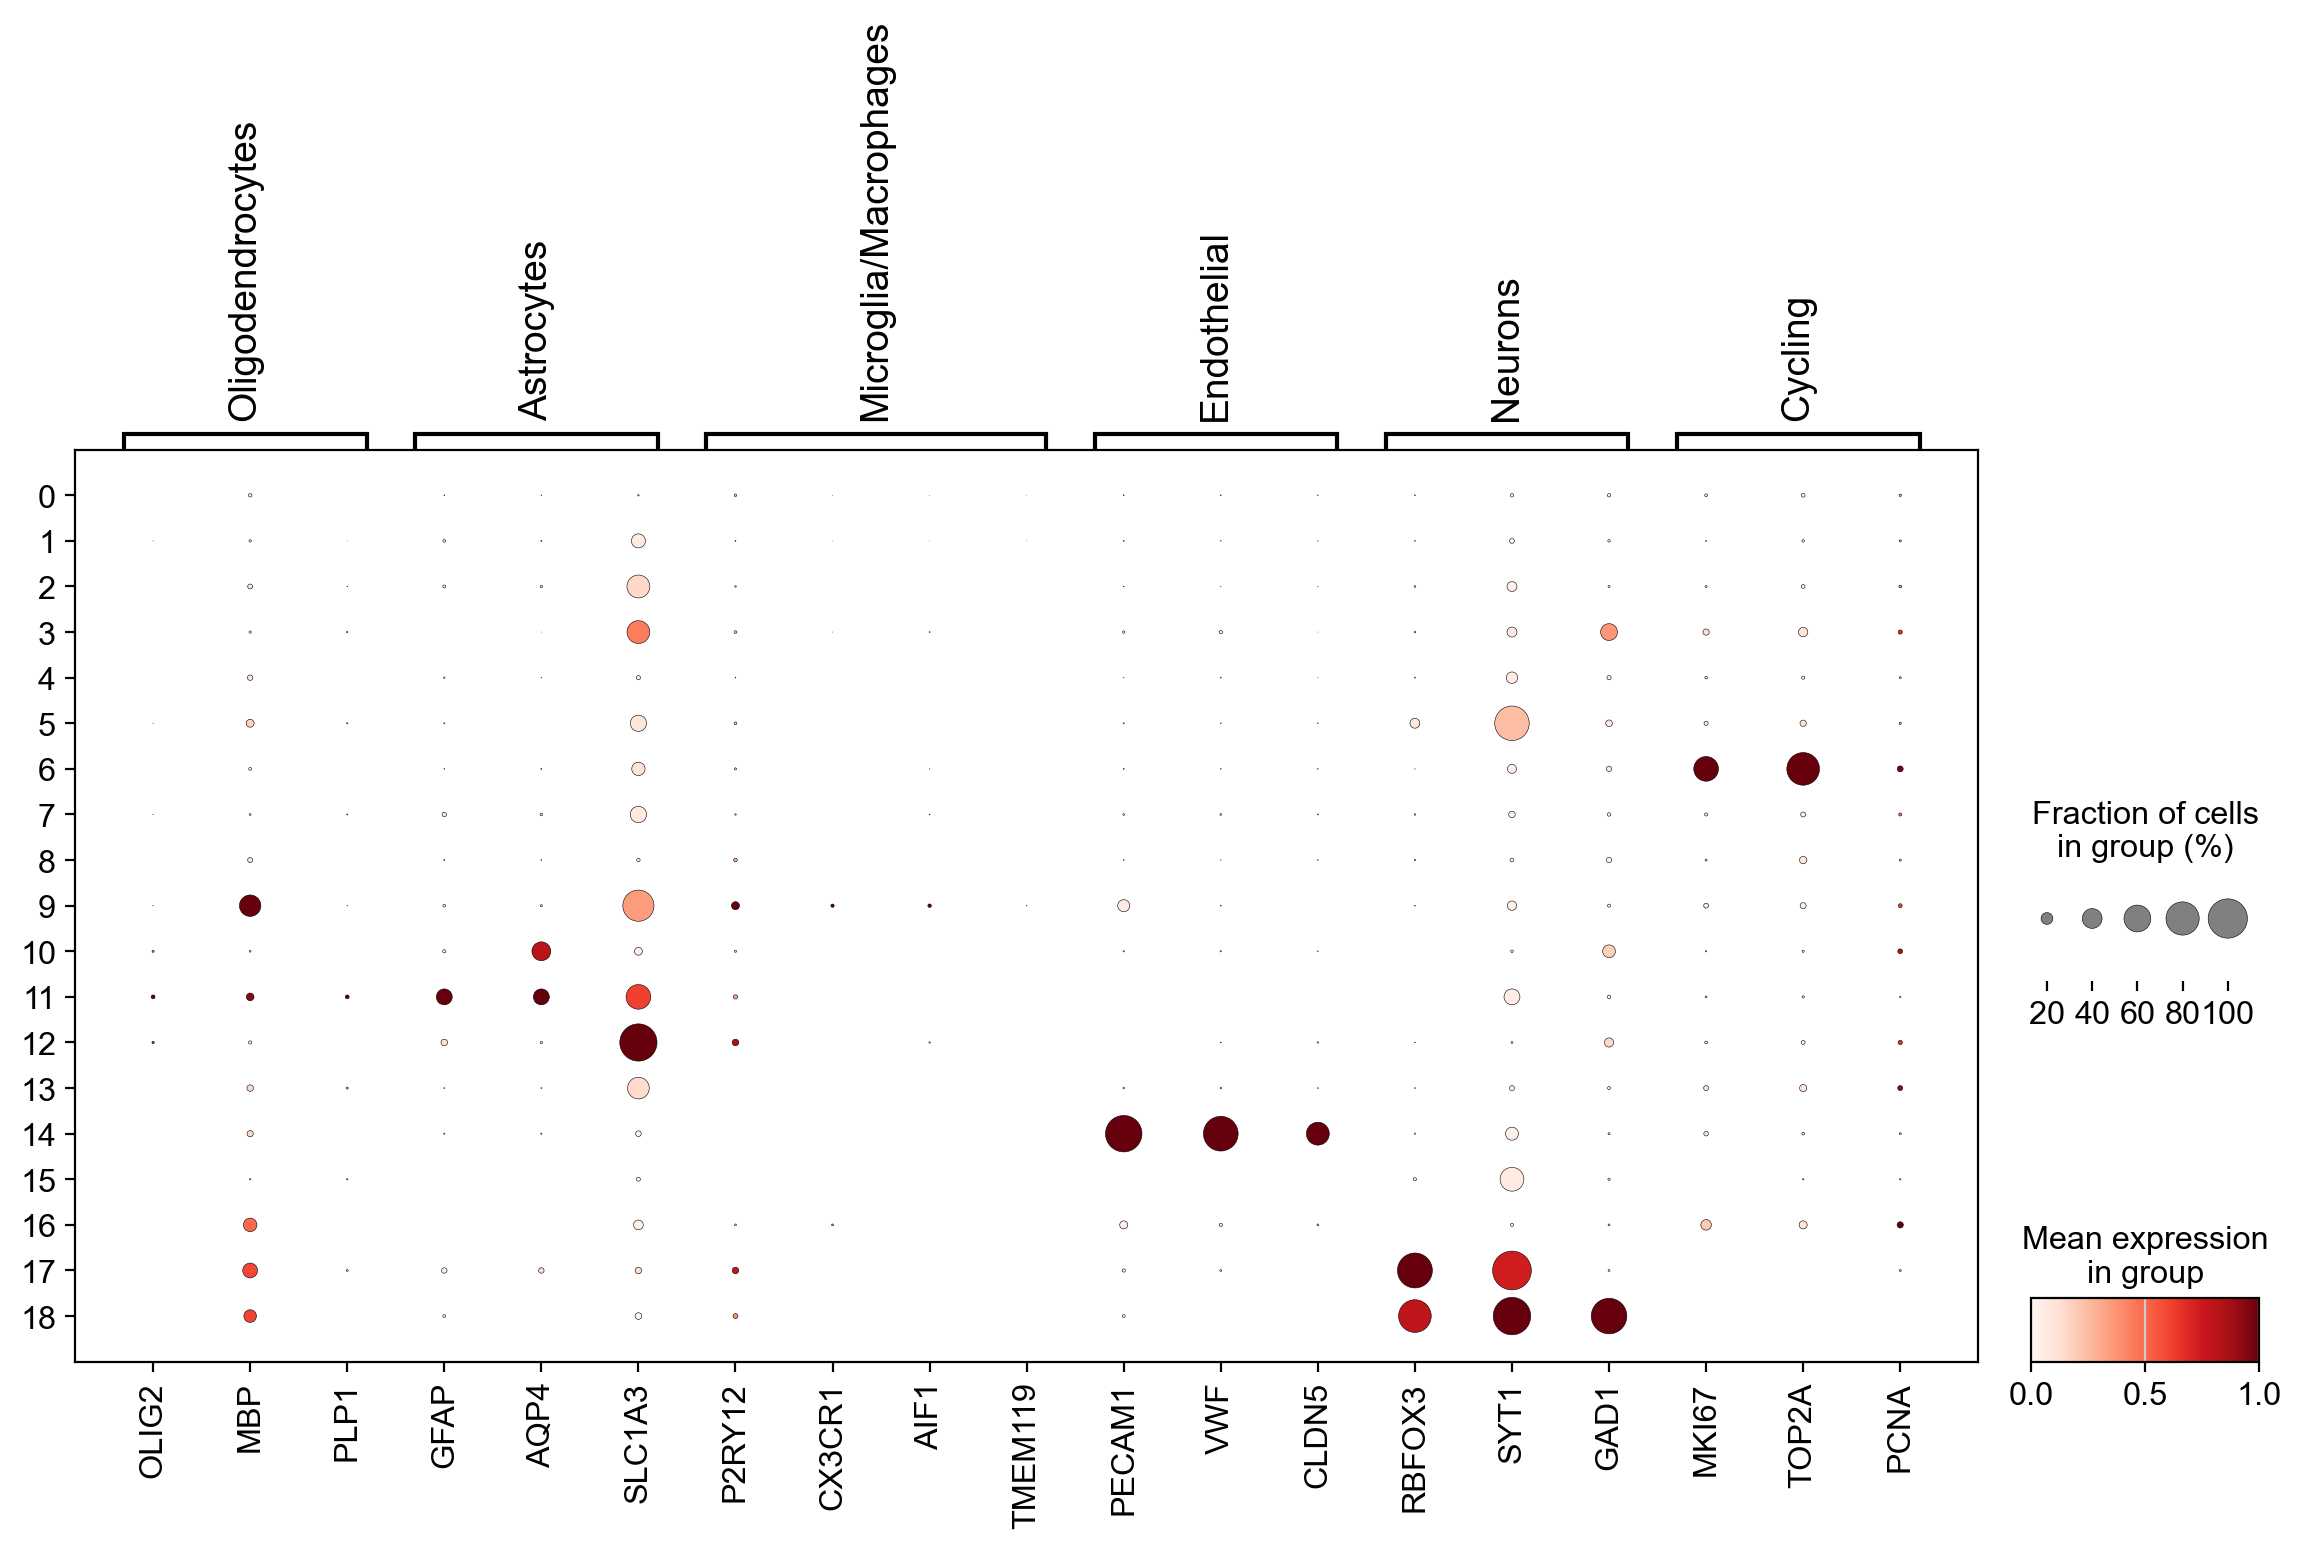

<Figure size 400x400 with 0 Axes>


>>> FIGURE 2C (dot plot): Saved to ~/ATRT/Data/Fig2C_marker_dotplot.png


In [6]:
# ============================================================
# FIGURE FOR REPORT: Dot plot of canonical markers → Figure 2C
# ============================================================

# Define canonical CNS cell type markers from Methods section
marker_genes = {
    'Oligodendrocytes': ['OLIG2', 'MBP', 'PLP1'],
    'Astrocytes': ['GFAP', 'AQP4', 'SLC1A3'],
    'Microglia/Macrophages': ['P2RY12', 'CX3CR1', 'AIF1', 'TMEM119'],
    'Endothelial': ['PECAM1', 'VWF', 'CLDN5'],
    'Neurons': ['RBFOX3', 'SYT1', 'GAD1'],
    'Cycling': ['MKI67', 'TOP2A', 'PCNA'],
}

# Check which markers are present in the dataset
all_markers = []
missing_markers = []
for cell_type, genes in marker_genes.items():
    for g in genes:
        if g in adata.raw.var_names:
            all_markers.append(g)
        else:
            missing_markers.append(g)

print(f"Markers found: {len(all_markers)}/{len(all_markers)+len(missing_markers)}")
if missing_markers:
    print(f"Missing markers: {missing_markers}")

# Create dot plot
sc.pl.dotplot(adata, var_names={k: [g for g in v if g in adata.raw.var_names] 
                                 for k, v in marker_genes.items()},
              groupby='leiden', use_raw=True, standard_scale='var',
              figsize=(14, 6))

plt.savefig(os.path.expanduser("~/ATRT/Data/Fig2C_marker_dotplot.png"), dpi=300, bbox_inches='tight')
plt.show()

print("\n>>> FIGURE 2C (dot plot): Saved to ~/ATRT/Data/Fig2C_marker_dotplot.png")

Cell 7 — Annotate clusters:

In [7]:
# ============================================================
# ANNOTATION: Based on marker expression, authors' labels, 
# and cross-tabulation, assign cell type labels.
# 
# UPDATE THE MAPPING BELOW after examining the dot plot (Cell 6),
# the cross-tabulation (Cell 4), and marker genes (Cell 5).
# ============================================================

# First, let's see which annotation dominates each cluster
print("Dominant author annotation per cluster:")
for cluster in sorted(adata.obs['leiden'].unique(), key=int):
    mask = adata.obs['leiden'] == cluster
    top_annot = adata.obs.loc[mask, 'Final_Annotation'].value_counts().head(3)
    n_cells = mask.sum()
    print(f"\nCluster {cluster} ({n_cells} nuclei):")
    for annot, count in top_annot.items():
        print(f"  {annot}: {count} ({count/n_cells*100:.1f}%)")

# ============================================================
# AFTER reviewing the above, fill in the mapping below.
# For now, we'll print a template — you can update it based 
# on what you see.
# ============================================================
print("\n\n>>> NEXT STEP: Review the output above and the dot plot.")
print(">>> Then update the cluster_annotation dict in the next cell.")
print(">>> Use the dominant author annotation + marker expression to decide.")

Dominant author annotation per cluster:

Cluster 0 (2183 nuclei):
  CP-like: 1763 (80.8%)
  Unannotated: 206 (9.4%)
  Cilia-like: 176 (8.1%)

Cluster 1 (1462 nuclei):
  Unannotated: 1182 (80.8%)
  CP-like: 162 (11.1%)
  Hypoxic: 66 (4.5%)

Cluster 2 (1237 nuclei):
  Unannotated: 1062 (85.9%)
  NPC-like: 76 (6.1%)
  CP-like: 57 (4.6%)

Cluster 3 (948 nuclei):
  Unannotated: 768 (81.0%)
  IPC-like: 76 (8.0%)
  Mesenchymal-like: 48 (5.1%)

Cluster 4 (652 nuclei):
  CP-like: 517 (79.3%)
  Unannotated: 100 (15.3%)
  IPC-like: 18 (2.8%)

Cluster 5 (614 nuclei):
  NPC-like: 394 (64.2%)
  Neurons: 139 (22.6%)
  Unannotated: 66 (10.7%)

Cluster 6 (398 nuclei):
  IPC-like: 323 (81.2%)
  Unannotated: 46 (11.6%)
  CP-like: 20 (5.0%)

Cluster 7 (386 nuclei):
  Unannotated: 263 (68.1%)
  CP-like: 54 (14.0%)
  Hypoxic: 23 (6.0%)

Cluster 8 (358 nuclei):
  Cilia-like: 310 (86.6%)
  CP-like: 28 (7.8%)
  Unannotated: 20 (5.6%)

Cluster 9 (328 nuclei):
  Microglia: 295 (89.9%)
  OPC-like: 11 (3.4%)
  Una

Cell 8 — Apply annotations (UPDATE AFTER REVIEWING CELL 7):

=== Cell Type Annotation Summary ===
cell_type
Tumor_Unannotated    2896
Tumor_CP-like        2835
Tumor_Mesenchymal     948
Tumor_NPC-like        700
Tumor_IPC-like        398
Microglia             386
Tumor_Hypoxic         386
Tumor_Cilia-like      358
Astrocytes            177
Tumor_OPC-like        173
Pericytes             155
Endothelial           105
Neurons                87
Name: count, dtype: int64

=== Tumor vs Non-malignant ===
malignancy
Tumor            8694
Non-malignant     910
Name: count, dtype: int64

>>> FOR REPORT:
>>> Tumor nuclei: 8694 (90.5%)
>>> Non-malignant nuclei: 910 (9.5%)


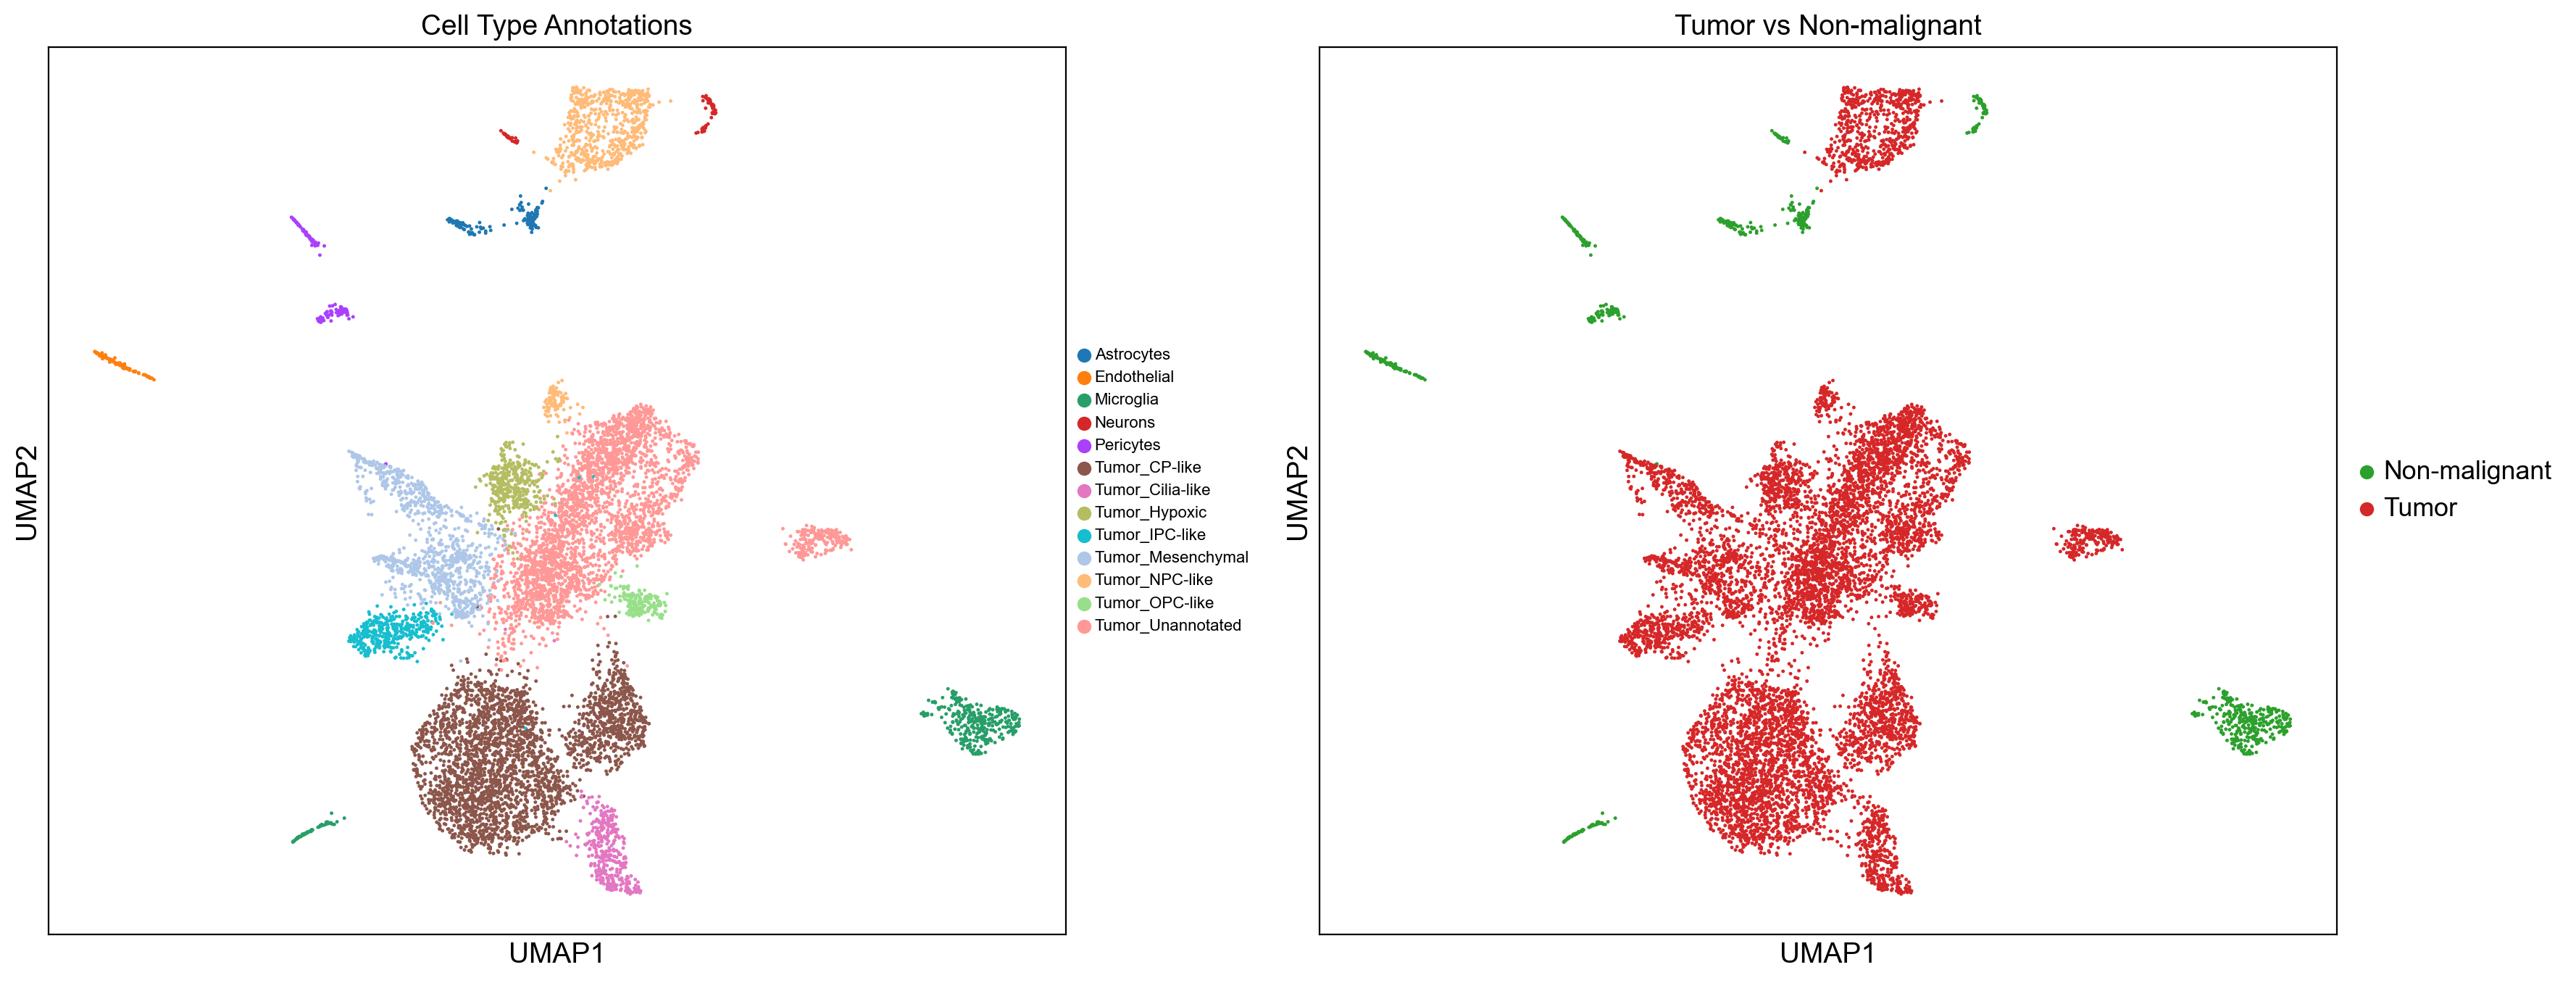


>>> FIGURE 2C (cell type UMAP): Saved to ~/ATRT/Data/Fig2C_celltype_UMAP.png


In [9]:
# ============================================================
# Cluster annotation based on:
# - Authors' Final_Annotation cross-tabulation (Cell 7)
# - Canonical marker dot plot (Cell 6)
# - Cluster marker genes (Cell 5)
#
# Tumor cells: clusters dominated by AT/RT-specific populations
#   (CP-like, Unannotated, Cilia-like, IPC-like, NPC-like, 
#    Mesenchymal-like, Hypoxic, OPC-like, RG-like)
# Non-malignant: clusters with clear normal CNS identity
#   (Microglia, Astrocytes, Endothelial, Pericytes, Neurons)
# ============================================================

cluster_annotation = {
    '0':  'Tumor_CP-like',         # 80.8% CP-like
    '1':  'Tumor_Unannotated',     # 80.8% Unannotated tumor
    '2':  'Tumor_Unannotated',     # 85.9% Unannotated + 6.1% NPC-like
    '3':  'Tumor_Mesenchymal',     # 81.0% Unannotated + 8.0% IPC + 5.1% Mesenchymal
    '4':  'Tumor_CP-like',         # 79.3% CP-like
    '5':  'Tumor_NPC-like',        # 64.2% NPC-like + 22.6% Neurons (tumor-derived)
    '6':  'Tumor_IPC-like',        # 81.2% IPC-like
    '7':  'Tumor_Hypoxic',         # 68.1% Unannotated + 14.0% CP + 6.0% Hypoxic
    '8':  'Tumor_Cilia-like',      # 86.6% Cilia-like
    '9':  'Microglia',             # 89.9% Microglia — NON-MALIGNANT
    '10': 'Tumor_Unannotated',     # 85.3% Unannotated + 6.6% OPC-like
    '11': 'Astrocytes',            # 46.3% Astrocytes + 4.0% OPC — NON-MALIGNANT
    '12': 'Tumor_OPC-like',        # 89.0% Unannotated + 6.9% OPC-like + 1.2% RG-like
    '13': 'Pericytes',             # 72.3% Pericytes — NON-MALIGNANT
    '14': 'Endothelial',           # 94.3% Endothelial — NON-MALIGNANT
    '15': 'Tumor_NPC-like',        # 51.2% NPC-like + 40.7% Unannotated
    '16': 'Microglia',             # 79.3% Microglia — NON-MALIGNANT
    '17': 'Neurons',               # 96.4% Neurons — NON-MALIGNANT
    '18': 'Neurons',               # 100% Neurons — NON-MALIGNANT
}

adata.obs['cell_type'] = adata.obs['leiden'].map(cluster_annotation).astype('category')

# Also create a simplified tumor vs non-malignant label
tumor_types = [ct for ct in cluster_annotation.values() if ct.startswith('Tumor')]
adata.obs['malignancy'] = adata.obs['cell_type'].apply(
    lambda x: 'Tumor' if x in tumor_types else 'Non-malignant'
).astype('category')

print("=== Cell Type Annotation Summary ===")
print(adata.obs['cell_type'].value_counts())
print(f"\n=== Tumor vs Non-malignant ===")
print(adata.obs['malignancy'].value_counts())

n_tumor = (adata.obs['malignancy'] == 'Tumor').sum()
n_nonmal = (adata.obs['malignancy'] == 'Non-malignant').sum()
print(f"\n>>> FOR REPORT:")
print(f">>> Tumor nuclei: {n_tumor} ({n_tumor/adata.n_obs*100:.1f}%)")
print(f">>> Non-malignant nuclei: {n_nonmal} ({n_nonmal/adata.n_obs*100:.1f}%)")

# ============================================================
# FIGURE FOR REPORT: Cell type annotated UMAP → Figure 2C
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sc.pl.umap(adata, color='cell_type', ax=axes[0], show=False, 
           title='Cell Type Annotations', legend_fontsize=8, 
           legend_loc='right margin')
sc.pl.umap(adata, color='malignancy', ax=axes[1], show=False, 
           title='Tumor vs Non-malignant',
           palette={'Tumor': '#d62728', 'Non-malignant': '#2ca02c'})

plt.tight_layout()
plt.savefig(os.path.expanduser("~/ATRT/Data/Fig2C_celltype_UMAP.png"), dpi=300, bbox_inches='tight')
plt.show()

print("\n>>> FIGURE 2C (cell type UMAP): Saved to ~/ATRT/Data/Fig2C_celltype_UMAP.png")

Cell 9 — Save:

In [10]:
# Save for Program 6 (ZMYM3 Expression Analysis)
output_path = os.path.expanduser("~/ATRT/Data/adata_annotated.h5ad")
adata.write(output_path)
print(f"Annotated AnnData saved to: {output_path}")
print(f"Shape: {adata.n_obs} nuclei x {adata.n_vars} genes")

print(f"\n>>> Program 5 complete!")
print(f">>> Key deliverables:")
print(f">>>   - Figure 2C: Leiden cluster UMAP")
print(f">>>   - Figure 2C: Canonical marker dot plot")
print(f">>>   - Figure 2C: Cell type annotated UMAP")
print(f">>>   - Cluster count for Methods section")
print(f"\n>>> Next: Program 6 (ZMYM3 Expression Analysis) — the main event!")

Annotated AnnData saved to: /Users/jacquelineli/ATRT/Data/adata_annotated.h5ad
Shape: 9604 nuclei x 36601 genes

>>> Program 5 complete!
>>> Key deliverables:
>>>   - Figure 2C: Leiden cluster UMAP
>>>   - Figure 2C: Canonical marker dot plot
>>>   - Figure 2C: Cell type annotated UMAP
>>>   - Cluster count for Methods section

>>> Next: Program 6 (ZMYM3 Expression Analysis) — the main event!
